# **Fine-Tuning unsloth/gemma-3n-E2B-it**

In [ ]:
https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Gemma3N_(4B)-Audio.ipynb#scrollTo=xnT9__SDcorj

configure colab environment for unsloth

In [ ]:
%%capture

import os
import re
import torch

v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)

xformers = 'xformers==' + {'2.10': '0.0.34', '2.9': '0.0.33.post1', '2.8': '0.0.32.post2'}.get(v, "0.0.34")

!pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
!pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install torchcodec

torch._dynamo.config.recompile_limit = 64


In [ ]:
%%capture
!pip install --no-deps --upgrade timm

In [ ]:
from unsloth import FastModel
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import json
from google.colab import drive
drive.mount('/content/drive')

random.seed(42)
DRIVE_DIR = "/content/drive/MyDrive/TextMiningProject/"
DATASET = os.path.join(DRIVE_DIR, "data")
os.makedirs(DATASET, exist_ok=True)

# Fine-Tuning


In [ ]:
!pip -q install modelscope

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 76.6 MB/s eta 0:00:00


In [ ]:
from unsloth.chat_templates import get_chat_template

## Audio Fine-Tuning

In [ ]:
from datasets import Dataset, Audio

ALL_DATA_JSON = os.path.join(DATASET, "all_data_train_processed.json")

with open(ALL_DATA_JSON, "r", encoding="utf-8") as f:
    all_data_train = json.load(f)
dataset_custom = Dataset.from_list(all_data_train)
dataset_custom = dataset_custom.rename_column("audio_path", "audio")

dataset_custom = dataset_custom.remove_columns(["text"])
dataset_custom = dataset_custom.rename_column("summary", "text")

dataset_custom = dataset_custom.cast_column("audio", Audio(sampling_rate=16000))
print(f"Total samples: {len(dataset_custom)}")

Total samples: 900


In [ ]:
from IPython.display import Audio, display
test_audio = dataset_custom[90]
print(test_audio['text']) # it's the golden summary
Audio(test_audio['audio']['array'],rate = test_audio['audio']['sampling_rate'])

Alien director Sir Ridley Scott has paid tribute to Swiss artist HR Giger, who has died aged 74 - describing him as "a true original".


---

In [ ]:
SYS_PROMPT = "You are a helpful summarization assistant."
PROMPT_AUDIO = "Summarize this audio in one sentence."

In [ ]:
os.environ['UNSLOTH_USE_MODELSCOPE'] = '1'

from unsloth import FastLanguageModel

model, processor = FastLanguageModel.from_pretrained(
    'unsloth/gemma-3n-E2B-it',
    dtype=None,
    load_in_4bit=True,
    token="token", # Put your token
    full_finetuning = False,
)


==((====))==  Unsloth 2026.2.1: Fast Gemma3N patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3n won't work! Using float32.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/2.65G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/469M [00:00<?, ?B/s]

...

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.70M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

In [ ]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False,  # Turn off for just text!
    finetune_language_layers   = True,  # Should leave on!
    finetune_attention_modules = True,  # Attention good for GRPO
    finetune_mlp_modules       = True,  # Should leave on always!

    r = 8,           # Larger = higher accuracy, but might overfit
    lora_alpha = 8,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",

        # Audio layers
        "post", "linear_start", "linear_end",
        "embedding_projection",
    ],
)

Unsloth: Making `model.base_model.model.model.language_model` require gradients


In [ ]:
def format_intersection_data(samples: dict) -> dict[str, list]:
    """Format intersection dataset to match expected message format"""
    formatted_samples = {"messages": []}
    for idx in range(len(samples["audio"])):
        audio = samples["audio"][idx]["array"]
        label = str(samples["text"][idx])

        message = [
            {
                "role": "system",
                "content": [
                    {
                        "type": "text",
                        "text": SYS_PROMPT,
                    }
                ],
            },
            {
                "role": "user",
                "content": [
                    {"type": "audio", "audio": audio},
                    {"type": "text", "text": PROMPT_AUDIO}
                ]
            },
            {
                "role": "assistant",
                "content":[{"type": "text", "text": label}]
            }
        ]
        formatted_samples["messages"].append(message)
    return formatted_samples

In [ ]:
dataset = dataset_custom.map(
    format_intersection_data,
    batched = True,
    batch_size = 4,
    remove_columns = dataset_custom.column_names
)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [ ]:
def collate_fn(examples):
    texts = []
    audios = []

    for example in examples:
        messages = example["messages"]
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        ).strip()
        texts.append(text)

        audio_array = messages[1]["content"][0]["audio"]
        audios.append(audio_array)

    batch = processor(
        text=texts,
        audio=audios,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=2048
    )

    labels = batch["input_ids"].clone()

    labels[labels == processor.tokenizer.pad_token_id] = -100


    response_marker = "<start_of_turn>model\n"
    marker_tokens = processor.tokenizer.encode(response_marker, add_special_tokens=False)

    for i in range(len(texts)):
        input_id_list = batch["input_ids"][i].tolist()

        found_marker = False
        for idx in range(len(input_id_list) - len(marker_tokens)):
            if input_id_list[idx : idx + len(marker_tokens)] == marker_tokens:
                labels[i, : idx + len(marker_tokens)] = -100
                found_marker = True
                break

        if not found_marker:
             pass

    special_tokens = ['image_token_id', 'audio_token_id', 'boi_token_id', 'eoi_token_id']
    for attr in special_tokens:
        if hasattr(processor.tokenizer, attr):
            token_id = getattr(processor.tokenizer, attr)
            if token_id is not None:
                labels[labels == token_id] = -100

    batch["labels"] = labels
    return batch

def collate_fn_sr24(examples):
    texts = []
    audios = []

    for example in examples:
        messages = example["messages"]
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        ).strip()
        texts.append(text)

        audio_array = messages[1]["content"][0]["audio"]
        audios.append(audio_array)

    batch = processor(
        text=texts,
        audio=audios,
        sampling_rate=24000,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=2048
    )

    labels = batch["input_ids"].clone()

    labels[labels == processor.tokenizer.pad_token_id] = -100


    response_marker = "<start_of_turn>model\n"
    marker_tokens = processor.tokenizer.encode(response_marker, add_special_tokens=False)

    for i in range(len(texts)):
        input_id_list = batch["input_ids"][i].tolist()

        found_marker = False
        for idx in range(len(input_id_list) - len(marker_tokens)):
            if input_id_list[idx : idx + len(marker_tokens)] == marker_tokens:
                labels[i, : idx + len(marker_tokens)] = -100
                found_marker = True
                break

        if not found_marker:
             pass

    special_tokens = ['image_token_id', 'audio_token_id', 'boi_token_id', 'eoi_token_id']
    for attr in special_tokens:
        if hasattr(processor.tokenizer, attr):
            token_id = getattr(processor.tokenizer, attr)
            if token_id is not None:
                labels[labels == token_id] = -100

    batch["labels"] = labels
    return batch

def collate_fn_sr8(examples):
    texts = []
    audios = []

    for example in examples:
        messages = example["messages"]
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        ).strip()
        texts.append(text)

        audio_array = messages[1]["content"][0]["audio"]
        audios.append(audio_array)

    batch = processor(
        text=texts,
        audio=audios,
        sampling_rate=8000,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=2048
    )

    labels = batch["input_ids"].clone()

    labels[labels == processor.tokenizer.pad_token_id] = -100


    response_marker = "<start_of_turn>model\n"
    marker_tokens = processor.tokenizer.encode(response_marker, add_special_tokens=False)

    for i in range(len(texts)):
        input_id_list = batch["input_ids"][i].tolist()

        found_marker = False
        for idx in range(len(input_id_list) - len(marker_tokens)):
            if input_id_list[idx : idx + len(marker_tokens)] == marker_tokens:
                labels[i, : idx + len(marker_tokens)] = -100
                found_marker = True
                break

        if not found_marker:
             pass

    special_tokens = ['image_token_id', 'audio_token_id', 'boi_token_id', 'eoi_token_id']
    for attr in special_tokens:
        if hasattr(processor.tokenizer, attr):
            token_id = getattr(processor.tokenizer, attr)
            if token_id is not None:
                labels[labels == token_id] = -100

    batch["labels"] = labels
    return batch

#### Fine-Tuning with processor sr=16000

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    train_dataset = dataset,
    processing_class = processor.tokenizer,
    data_collator = collate_fn,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 16,
        gradient_checkpointing_kwargs = {"use_reentrant": False},
        warmup_ratio = 0.1,
        max_steps = 120,
        #num_train_epochs = 2,
        learning_rate = 2e-4,
        logging_steps = 1,
        save_strategy = "steps",
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 2,
        max_length = 2048,
        label_names = ["labels"],
    )
)

trainer_stats = trainer.train()

Unsloth: Switching to float32 training since model cannot work with float16


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 900 | Num Epochs = 5 | Total steps = 120
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 12,546,048 of 5,451,984,320 (0.23% trained)


Step,Training Loss
1,8.849500
2,8.637200
3,4.869500
4,5.311700
5,4.665400
6,4.626700
7,4.484500
8,4.473100
9,4.633100
10,4.232600


In [ ]:
drive_path = os.path.join(DRIVE_DIR, "fine_tuning_audio_sr16")
os.makedirs(drive_path, exist_ok=True)

model.save_pretrained(f"{drive_path}/gemma_lora_audio")
processor.save_pretrained(f"{drive_path}/gemma_processor_audio")

#### Fine-Tuning with processor sr=24000

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    train_dataset = dataset,
    processing_class = processor.tokenizer,
    data_collator = collate_fn_sr24,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 16,
        gradient_checkpointing_kwargs = {"use_reentrant": False},
        warmup_ratio = 0.1,
        max_steps = 120,
        #num_train_epochs = 2,
        learning_rate = 2e-4,
        logging_steps = 1,
        save_strategy = "steps",
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 2,
        max_length = 2048,
        label_names = ["labels"],
    )
)

trainer_stats = trainer.train()

Unsloth: Switching to float32 training since model cannot work with float16


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 900 | Num Epochs = 5 | Total steps = 120
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 12,546,048 of 5,451,984,320 (0.23% trained)


Step,Training Loss
1,8.849700
2,8.637200
3,4.870200
4,5.288400
5,4.670000
6,4.635100
7,4.509200
8,4.462500
9,4.647200
10,4.240700


In [ ]:
drive_path = os.path.join(DRIVE_DIR, "fine_tuning_audio_sr24")
os.makedirs(drive_path, exist_ok=True)

model.save_pretrained(f"{drive_path}/gemma_lora_audio")
processor.save_pretrained(f"{drive_path}/gemma_processor_audio")

['/content/drive/MyDrive/TextMiningProject/fine_tuning_audio_sr24/gemma_processor_audio/processor_config.json']

#### Fine-Tuning with processor sr=8000

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    train_dataset = dataset,
    processing_class = processor.tokenizer,
    data_collator = collate_fn_sr8,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 16,
        gradient_checkpointing_kwargs = {"use_reentrant": False},
        warmup_ratio = 0.1,
        max_steps = 120,
        #num_train_epochs = 2,
        learning_rate = 2e-4,
        logging_steps = 1,
        save_strategy = "steps",
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 2,
        max_length = 2048,
        label_names = ["labels"],
    )
)

trainer_stats = trainer.train()

Unsloth: Switching to float32 training since model cannot work with float16


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 900 | Num Epochs = 5 | Total steps = 120
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 12,546,048 of 5,451,984,320 (0.23% trained)


Step,Training Loss
1,8.849700
2,8.637200
3,4.870400
4,5.283100
5,4.668700
6,4.633900
7,4.509700
8,4.462400
9,4.646100
10,4.239100


In [ ]:
drive_path = os.path.join(DRIVE_DIR, "fine_tuning_audio_sr8")
os.makedirs(drive_path, exist_ok=True)

model.save_pretrained(f"{drive_path}/gemma_lora_audio")
processor.save_pretrained(f"{drive_path}/gemma_processor_audio")

['/content/drive/MyDrive/TextMiningProject/fine_tuning_audio_sr8/gemma_processor_audio/processor_config.json']

#### Training comparison

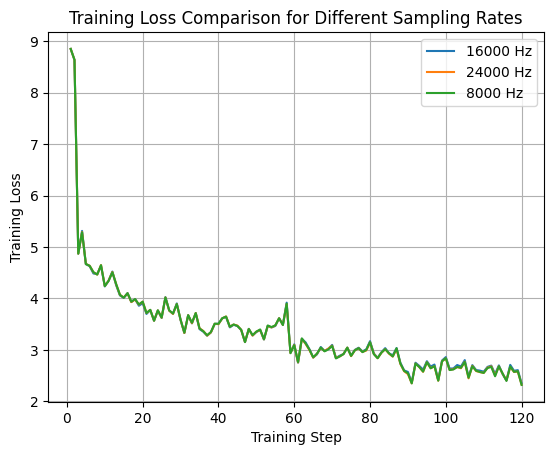

In [ ]:
import matplotlib.pyplot as plt

# =========================
# Training Loss - 16000 Hz
# =========================
loss_16000 = [
8.849500,8.637200,4.869500,5.311700,4.665400,4.626700,4.484500,4.473100,4.633100,4.232600,
4.343300,4.521600,4.255200,4.057400,4.011600,4.101300,3.932900,3.984000,3.857200,3.908400,
3.698000,3.772500,3.566000,3.762900,3.619200,4.024100,3.765800,3.700800,3.901900,3.578200,
3.327100,3.671900,3.514900,3.710900,3.402800,3.352800,3.274500,3.339100,3.501000,3.507700,
3.612500,3.641100,3.436600,3.487200,3.462500,3.384600,3.149800,3.408300,3.279100,3.347400,
3.382700,3.201400,3.462800,3.435000,3.464000,3.613100,3.488100,3.917100,2.944700,3.106500,
2.750800,3.213600,3.143900,3.011600,2.851400,2.912400,3.054300,2.977800,3.019400,3.095500,
2.841200,2.885400,2.919100,3.041700,2.886200,2.999300,3.040700,2.968800,3.008300,3.168200,
2.928100,2.844100,2.951900,3.032900,2.932500,2.893000,3.034100,2.750200,2.599900,2.569900,
2.365300,2.748600,2.687000,2.614100,2.778400,2.674600,2.714000,2.414400,2.792300,2.858300,
2.634600,2.638700,2.704700,2.675200,2.800500,2.474900,2.702400,2.606600,2.595800,2.574300,
2.668300,2.693300,2.532600,2.697100,2.526700,2.404200,2.707200,2.591900,2.604900,2.349500
]

# =========================
# Training Loss - 24000 Hz
# =========================
loss_24000 = [
8.849700,8.637200,4.870200,5.288400,4.670000,4.635100,4.509200,4.462500,4.647200,4.240700,
4.344700,4.512500,4.274400,4.068200,4.018000,4.097500,3.927200,3.980100,3.879700,3.935500,
3.715400,3.775700,3.566600,3.765100,3.624700,4.018100,3.761600,3.698500,3.888900,3.584400,
3.326900,3.672400,3.517600,3.715900,3.419100,3.366600,3.277100,3.338200,3.506000,3.498800,
3.611800,3.649100,3.450400,3.491900,3.471100,3.387400,3.152600,3.404800,3.275900,3.353000,
3.387400,3.203500,3.464900,3.435300,3.474200,3.614100,3.484600,3.891200,2.939400,3.095900,
2.754000,3.212900,3.114600,2.996300,2.848400,2.925400,3.039300,2.976500,3.024700,3.081300,
2.842000,2.870900,2.918400,3.042500,2.877200,2.991600,3.029600,2.958800,2.986100,3.144500,
2.922400,2.837000,2.941600,3.012800,2.926200,2.868100,3.016200,2.726400,2.583800,2.528000,
2.349000,2.732100,2.665400,2.572500,2.758000,2.642300,2.680900,2.399700,2.777100,2.834000,
2.608600,2.624500,2.665300,2.642100,2.767800,2.445800,2.688500,2.586600,2.567200,2.550400,
2.653100,2.679100,2.501100,2.677900,2.533800,2.405600,2.666400,2.569600,2.578100,2.322200
]

# =========================
# Training Loss - 8000 Hz
# =========================
loss_8000 = [
8.849700,8.637200,4.870400,5.283100,4.668700,4.633900,4.509700,4.462400,4.646100,4.239100,
4.340800,4.506700,4.279600,4.069600,4.012500,4.101400,3.934000,3.987300,3.882800,3.937000,
3.716500,3.777600,3.566300,3.768300,3.628200,4.018300,3.765900,3.705600,3.889400,3.586100,
3.333600,3.674300,3.525700,3.714800,3.415100,3.360900,3.284200,3.346300,3.509200,3.505100,
3.614100,3.646200,3.448600,3.492700,3.464700,3.389600,3.150700,3.405100,3.285200,3.354300,
3.396500,3.205600,3.473900,3.442400,3.476300,3.614100,3.481700,3.897800,2.933700,3.090700,
2.760900,3.222400,3.124700,3.004800,2.854400,2.927400,3.043000,2.970800,3.009200,3.075000,
2.832900,2.872400,2.917600,3.042400,2.882000,2.992000,3.031800,2.955000,2.998200,3.148700,
2.916000,2.836800,2.945500,3.013200,2.933500,2.871100,3.030200,2.734200,2.590400,2.545200,
2.347400,2.732400,2.664800,2.577100,2.759100,2.640900,2.683900,2.400500,2.777300,2.835800,
2.607000,2.618700,2.666500,2.651900,2.764500,2.457000,2.681500,2.593100,2.569200,2.551400,
2.645500,2.668700,2.485900,2.678800,2.539100,2.396300,2.677100,2.572200,2.583900,2.317800
]

steps = list(range(1, 121))

plt.figure()
plt.plot(steps, loss_16000, label="16000 Hz")
plt.plot(steps, loss_24000, label="24000 Hz")
plt.plot(steps, loss_8000, label="8000 Hz")

plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison for Different Sampling Rates")
plt.legend()
plt.grid(True)

plt.show()

Here we can see that the training loss for the three fine-tuning follows the same trajectory.

### Try with less steps and smaller lr

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    train_dataset = dataset,
    processing_class = processor.tokenizer,
    data_collator = collate_fn,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 16,
        gradient_checkpointing_kwargs = {"use_reentrant": False},
        warmup_ratio = 0.1,
        #max_steps = 60,
        num_train_epochs = 2,
        learning_rate = 1e-5,
        logging_steps = 1,
        save_strategy = "steps",
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 2,
        max_length = 2048,
        label_names = ["labels"],
    )
)

trainer_stats = trainer.train()

Unsloth: Switching to float32 training since model cannot work with float16


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 900 | Num Epochs = 2 | Total steps = 58
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 12,546,048 of 5,451,984,320 (0.23% trained)


Step,Training Loss
1,8.849500
2,8.637200
3,4.865300
4,5.004800
5,4.719600
6,4.601300
7,4.523600
8,4.539800
9,4.685700
10,4.277800


The convergence of the fine-tuning seems slower wrt the previous fine-tunings

## Text Fine-Tuning

In [ ]:
os.environ['UNSLOTH_USE_MODELSCOPE'] = '1'

from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    'unsloth/gemma-3n-E2B-it',
    dtype=None,
    load_in_4bit=True,
    token="token", # Put your token
    full_finetuning = False,
)

==((====))==  Unsloth 2026.2.1: Fast Gemma3N patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3n won't work! Using float32.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/2.65G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/469M [00:00<?, ?B/s]

...

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.70M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

In [ ]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False,  # Turn off for just text!
    finetune_language_layers   = True,  # Should leave on!
    finetune_attention_modules = True,  # Attention good for GRPO
    finetune_mlp_modules       = True,  # Should leave on always!

    r = 8,           # Larger = higher accuracy, but might overfit
    lora_alpha = 8,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
)

Unsloth: Making `model.base_model.model.model.language_model` require gradients


In [ ]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma-3",
)

In [ ]:
ALL_DATA_JSON = os.path.join(DATASET, "all_data_train_processed.json")

with open(ALL_DATA_JSON, "r", encoding="utf-8") as f:
    all_data_train = json.load(f)
    print(f"Loaded all_data from {ALL_DATA_JSON}")
    print(f"Total samples: {len(all_data_train)}")

Loaded all_data from /content/drive/MyDrive/TextMiningProject/data/all_data_train_processed.json
Total samples: 900


In [ ]:
from datasets import Dataset
from unsloth.chat_templates import standardize_data_formats

dataset = Dataset.from_list(all_data_train)
dataset = standardize_data_formats(dataset)

In [ ]:
dataset[100]

{'id': 'xsum_100',
 'text': 'Security forces retook the Naso-Hablod hotel after gunmen stormed it and took hostages, officials said.\nThose killed are reported to include security guards, civilians and some of the attackers.\nAl-Shabab militants frequently carry out attacks in the city in their bid to topple the Western-backed government.\nA suicide bomber first detonated a car with explosives at the gate of the hotel, and the attackers moved in, officials said.\nOnce inside, the gunmen shot randomly at guests, a witness said.\n',
 'summary': 'An attack by the Islamist group al-Shabab in a hotel in the Somali capital Mogadishu has left at least 14 dead, police say.',
 'dataset': 'xsum',
 'audio_path': '/content/drive/MyDrive/TextMiningProject/data/audio_train_preprocessed/xsum_100.wav'}

In [ ]:
SYS_PROMPT = "You are a helpful summarization assistant."
PROMPT_TEXT = "Summarize this text in one sentence."

def transform_to_conversational(example):
    conversations = [
        {
            "role": "system",
            "content": SYS_PROMPT
        },
        {
            "role": "user",
            "content": f"{PROMPT_TEXT}: {example['text']}"
        },
        {
            "role": "assistant",
            "content": example['summary']
        }
    ]

    return {
        "conversations": conversations,
        "source": example.get("dataset", "unknown"),
    }

dataset_formatted = dataset.map(
    transform_to_conversational,
    remove_columns=dataset.column_names
)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [ ]:
dataset_formatted[100]

{'conversations': [{'content': 'You are a helpful summarization assistant.',
   'role': 'system'},
  {'content': 'Summarize this text in one sentence.: Security forces retook the Naso-Hablod hotel after gunmen stormed it and took hostages, officials said.\nThose killed are reported to include security guards, civilians and some of the attackers.\nAl-Shabab militants frequently carry out attacks in the city in their bid to topple the Western-backed government.\nA suicide bomber first detonated a car with explosives at the gate of the hotel, and the attackers moved in, officials said.\nOnce inside, the gunmen shot randomly at guests, a witness said.\n',
   'role': 'user'},
  {'content': 'An attack by the Islamist group al-Shabab in a hotel in the Somali capital Mogadishu has left at least 14 dead, police say.',
   'role': 'assistant'}],
 'source': 'xsum'}

In [ ]:
def formatting_prompts_func(examples):
   convos = examples["conversations"]
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False).removeprefix('<bos>') for convo in convos]
   return { "text" : texts, }

dataset = dataset_formatted.map(formatting_prompts_func, batched = True)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [ ]:
dataset[100]["text"]

'<start_of_turn>user\nYou are a helpful summarization assistant.\n\nSummarize this text in one sentence.: Security forces retook the Naso-Hablod hotel after gunmen stormed it and took hostages, officials said.\nThose killed are reported to include security guards, civilians and some of the attackers.\nAl-Shabab militants frequently carry out attacks in the city in their bid to topple the Western-backed government.\nA suicide bomber first detonated a car with explosives at the gate of the hotel, and the attackers moved in, officials said.\nOnce inside, the gunmen shot randomly at guests, a witness said.<end_of_turn>\n<start_of_turn>model\nAn attack by the Islamist group al-Shabab in a hotel in the Somali capital Mogadishu has left at least 14 dead, police say.<end_of_turn>\n'

In [ ]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    eval_dataset = None, # Can set up evaluation!
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 16, # Use GA to mimic batch size!
        warmup_steps = 5,
        num_train_epochs = 2, # Set this for 1 full training run.
        # max_steps = 60,
        learning_rate = 2e-4, # Reduce to 2e-5 for long training runs
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none", # Use TrackIO/WandB etc
    ),
)

Unsloth: Switching to float32 training since model cannot work with float16


In [ ]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part = "<start_of_turn>model\n",
)

Map (num_proc=6):   0%|          | 0/900 [00:00<?, ? examples/s]

Map (num_proc=6):   0%|          | 0/900 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/900 [00:00<?, ? examples/s]

In [ ]:
tokenizer.decode(trainer.train_dataset[100]["input_ids"])

'<bos><start_of_turn>user\nYou are a helpful summarization assistant.\n\nSummarize this text in one sentence.: Security forces retook the Naso-Hablod hotel after gunmen stormed it and took hostages, officials said.\nThose killed are reported to include security guards, civilians and some of the attackers.\nAl-Shabab militants frequently carry out attacks in the city in their bid to topple the Western-backed government.\nA suicide bomber first detonated a car with explosives at the gate of the hotel, and the attackers moved in, officials said.\nOnce inside, the gunmen shot randomly at guests, a witness said.<end_of_turn>\n<start_of_turn>model\nAn attack by the Islamist group al-Shabab in a hotel in the Somali capital Mogadishu has left at least 14 dead, police say.<end_of_turn>\n'

In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 900 | Num Epochs = 2 | Total steps = 58
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 10,567,680 of 5,450,005,952 (0.19% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,10.942500
2,10.858900
3,5.733300
4,5.114300
5,4.654700
6,4.432200
7,3.978900
8,3.902700
9,4.017500
10,3.609000


In [ ]:
drive_path = os.path.join(DRIVE_DIR, "fine_tuning_text")
os.makedirs(drive_path, exist_ok=True)

model.save_pretrained(f"{drive_path}/gemma_lora_text_v1")
tokenizer.save_pretrained(f"{drive_path}/gemma_processor_text_v1")

['/content/drive/MyDrive/TextMiningProject/fine_tuning_text/qwen_processor_text_v1/processor_config.json']